# Healthcare Dataset — Data Cleaning, Length of Stay & Feature Engineering

**Dataset:** `healthcare_dataset.csv` (55,500 patient admission records, 15 fields)

This notebook covers:
1. Data Loading & Inspection
2. Data Cleaning
3. Length of Stay Calculation
4. Admission Trends
5. Feature Engineering
6. Export engineered dataset for downstream billing analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

df = pd.read_csv("healthcare_dataset.csv")
print(df.shape)
df.head()

(55500, 15)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## 1. Data Loading & Inspection

In [2]:
df.dtypes

Name                      str
Age                     int64
Gender                    str
Blood Type                str
Medical Condition         str
Date of Admission         str
Doctor                    str
Hospital                  str
Insurance Provider        str
Billing Amount        float64
Room Number             int64
Admission Type            str
Discharge Date            str
Medication                str
Test Results              str
dtype: object

In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Name,55500,49992,DAvId muNoZ,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,55500.0,NaN,NaN,NaN,51.539459,19.602454,13.0,35.0,52.0,68.0,89.0
Gender,55500,2,Male,27774,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Blood Type,55500,8,A-,6969,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medical Condition,55500,6,Arthritis,9308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date of Admission,55500,1827,2024-03-16,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Doctor,55500,40341,Michael Smith,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hospital,55500,39876,LLC Smith,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Insurance Provider,55500,5,Cigna,11249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Billing Amount,55500.0,NaN,NaN,NaN,25539.316097,14211.454431,-2008.49214,13241.224652,25538.069376,37820.508436,52764.276736


## 2. Data Cleaning

Steps:
- Remove exact duplicate rows
- Standardize `Name` casing (source data has random/mixed case)
- Parse admission & discharge dates
- Handle negative `Billing Amount` values (data entry errors — take absolute value)
- Check `Discharge Date` >= `Date of Admission`

In [4]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dedup:", df.shape)

Duplicate rows: 534
Shape after dedup: (54966, 15)


In [5]:
print("Sample of raw Name casing:", df['Name'].head(5).tolist())
df["Name"] = df["Name"].str.strip().str.title()
print("After cleaning:", df['Name'].head(5).tolist())

Sample of raw Name casing: ['Bobby JacksOn', 'LesLie TErRy', 'DaNnY sMitH', 'andrEw waTtS', 'adrIENNE bEll']
After cleaning: ['Bobby Jackson', 'Leslie Terry', 'Danny Smith', 'Andrew Watts', 'Adrienne Bell']


In [6]:
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"])

invalid_dates = (df["Discharge Date"] < df["Date of Admission"]).sum()
print("Rows where Discharge Date precedes Admission Date:", invalid_dates)

Rows where Discharge Date precedes Admission Date: 0


In [7]:
neg_billing = (df["Billing Amount"] < 0).sum()
print(f"Negative billing amounts: {neg_billing} ({neg_billing/len(df)*100:.2f}%)")

df["Billing Amount"] = df["Billing Amount"].abs()
print("Negative values remaining:", (df["Billing Amount"] < 0).sum())

Negative billing amounts: 106 (0.19%)
Negative values remaining: 0


In [8]:
for c in ["Gender", "Blood Type", "Medical Condition", "Insurance Provider", "Admission Type", "Test Results", "Medication", "Doctor", "Hospital"]:
    df[c] = df[c].astype(str).str.strip()

print("Missing values per column:")
df.isna().sum()

Missing values per column:


Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

## 3. Length of Stay Calculation

`Length_of_Stay` = Discharge Date − Date of Admission (in days).

In [9]:
df["Length_of_Stay"] = (df["Discharge Date"] - df["Date of Admission"]).dt.days

df["Length_of_Stay"].describe()

count    54966.000000
mean        15.499290
std          8.661471
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Length_of_Stay, dtype: float64

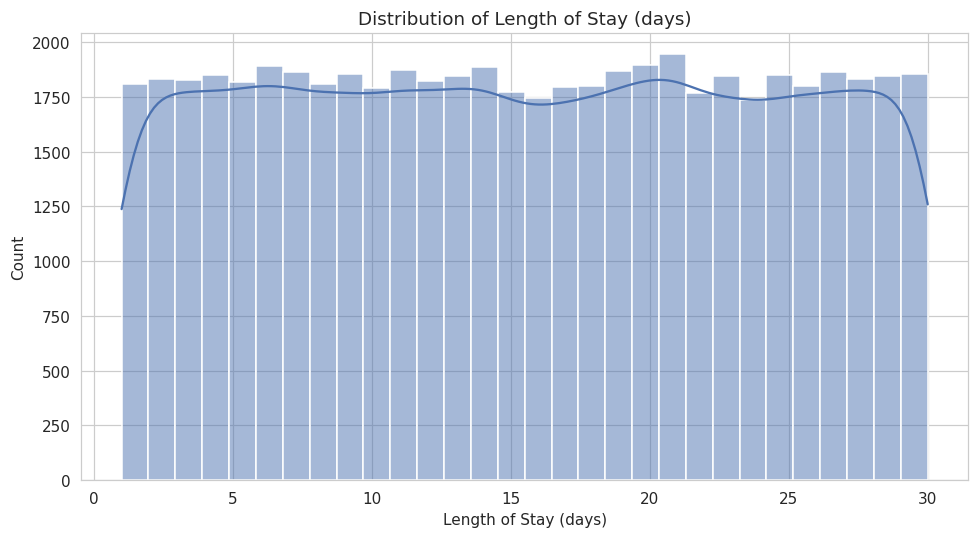

In [10]:
plt.figure(figsize=(9, 5))
sns.histplot(df["Length_of_Stay"], bins=30, kde=True, color="#4C72B0")
plt.title("Distribution of Length of Stay (days)")
plt.xlabel("Length of Stay (days)")
plt.tight_layout()
plt.show()

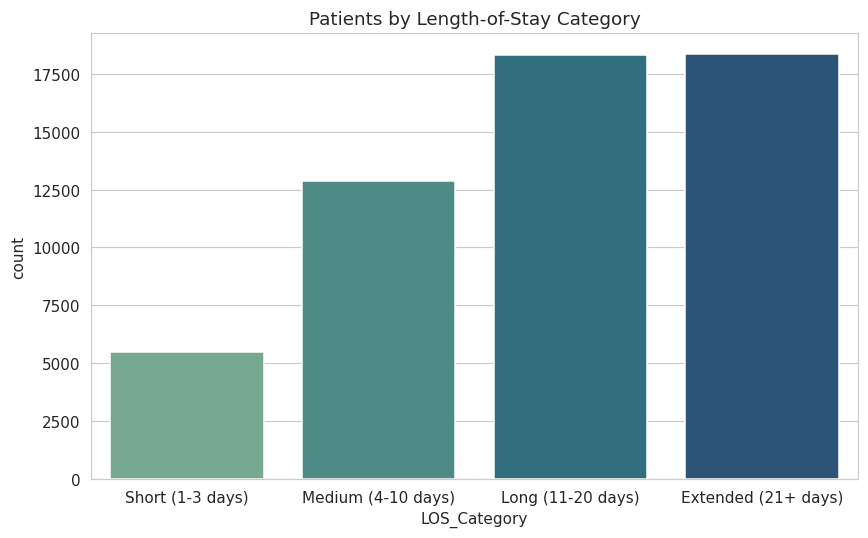

LOS_Category
Short (1-3 days)        5466
Medium (4-10 days)     12871
Long (11-20 days)      18294
Extended (21+ days)    18335
Name: count, dtype: int64

In [11]:
def los_category(days):
    if days <= 3:
        return "Short (1-3 days)"
    elif days <= 10:
        return "Medium (4-10 days)"
    elif days <= 20:
        return "Long (11-20 days)"
    else:
        return "Extended (21+ days)"

df["LOS_Category"] = df["Length_of_Stay"].apply(los_category)
order_los = ["Short (1-3 days)", "Medium (4-10 days)", "Long (11-20 days)", "Extended (21+ days)"]

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="LOS_Category", order=order_los, hue="LOS_Category", legend=False, palette="crest")
plt.title("Patients by Length-of-Stay Category")
plt.tight_layout()
plt.show()

df["LOS_Category"].value_counts().reindex(order_los)

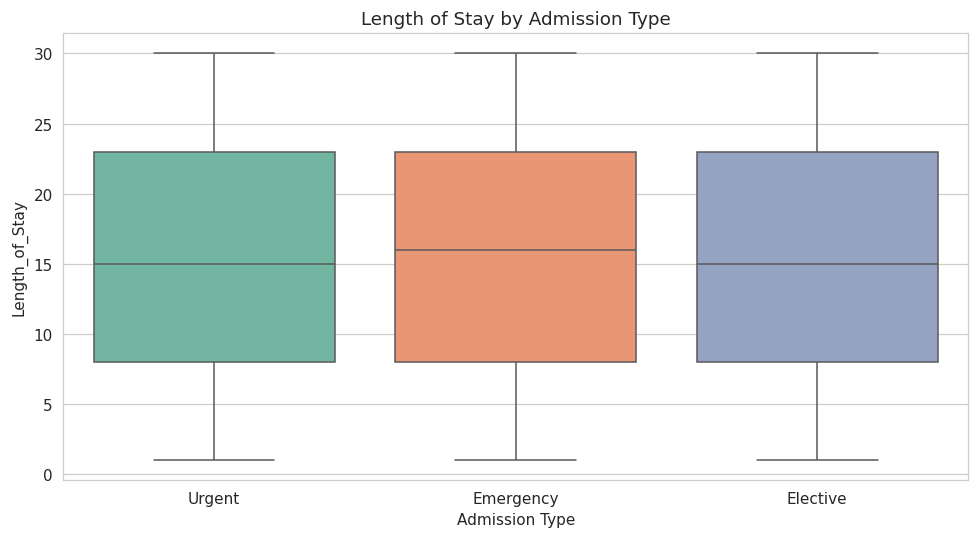

Admission Type
Elective     15.51
Emergency    15.58
Urgent       15.40
Name: Length_of_Stay, dtype: float64

In [12]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Admission Type", y="Length_of_Stay", hue="Admission Type", legend=False, palette="Set2")
plt.title("Length of Stay by Admission Type")
plt.tight_layout()
plt.show()

df.groupby("Admission Type")["Length_of_Stay"].mean().round(2)

## 4. Admission Trends

Examine how admissions vary over time — by year, month, and day of week — and by admission type.

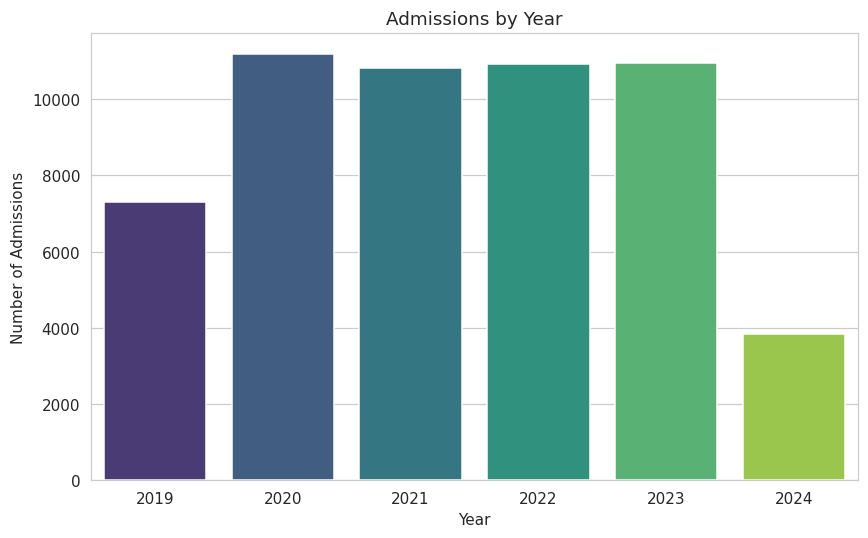

Admission_Year
2019     7300
2020    11172
2021    10816
2022    10915
2023    10936
2024     3827
Name: count, dtype: int64

In [13]:
df["Admission_Year"] = df["Date of Admission"].dt.year
df["Admission_Month"] = df["Date of Admission"].dt.month
df["Admission_DayOfWeek"] = df["Date of Admission"].dt.day_name()

yearly = df["Admission_Year"].value_counts().sort_index()
plt.figure(figsize=(8, 5))
sns.barplot(x=yearly.index.astype(str), y=yearly.values, hue=yearly.index.astype(str), legend=False, palette="viridis")
plt.title("Admissions by Year")
plt.xlabel("Year")
plt.ylabel("Number of Admissions")
plt.tight_layout()
plt.show()
yearly

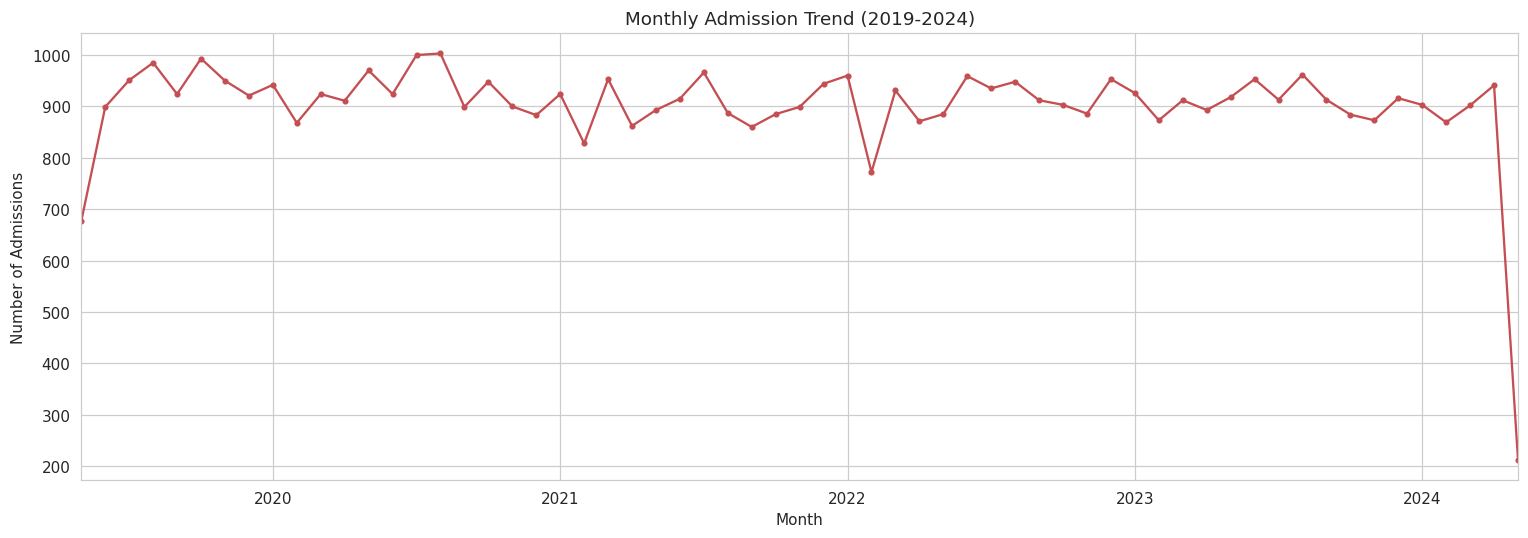

In [14]:
monthly = df.groupby(df["Date of Admission"].dt.to_period("M")).size()

plt.figure(figsize=(14, 5))
monthly.plot(kind="line", marker="o", color="#C44E52", markersize=3)
plt.title("Monthly Admission Trend (2019-2024)")
plt.xlabel("Month")
plt.ylabel("Number of Admissions")
plt.tight_layout()
plt.show()

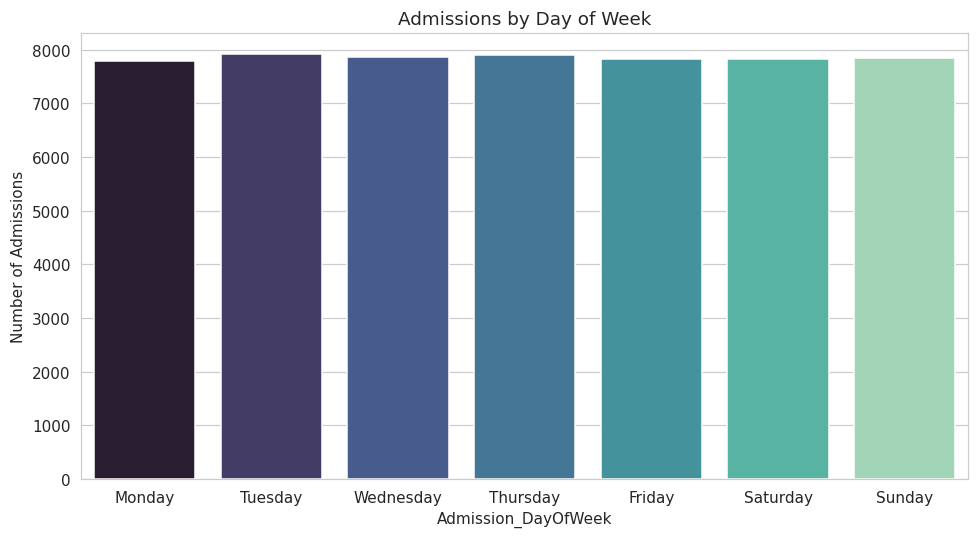

Admission_DayOfWeek
Monday       7781
Tuesday      7913
Wednesday    7873
Thursday     7909
Friday       7818
Saturday     7822
Sunday       7850
Name: count, dtype: int64

In [15]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_counts = df["Admission_DayOfWeek"].value_counts().reindex(dow_order)

plt.figure(figsize=(9, 5))
sns.barplot(x=dow_counts.index, y=dow_counts.values, hue=dow_counts.index, legend=False, palette="mako")
plt.title("Admissions by Day of Week")
plt.ylabel("Number of Admissions")
plt.tight_layout()
plt.show()
dow_counts

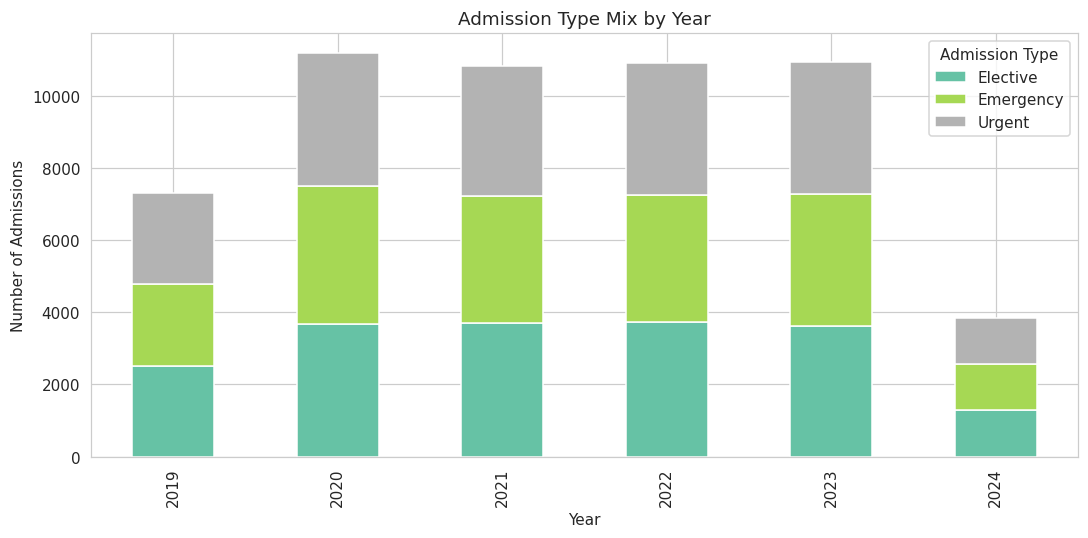

Admission Type,Elective,Emergency,Urgent
Date of Admission,,,
2019,2496,2288,2516
2020,3671,3818,3683
2021,3688,3532,3596
2022,3725,3524,3666
2023,3607,3662,3667
2024,1286,1278,1263


In [16]:
admission_type_trend = df.groupby([df["Date of Admission"].dt.year, "Admission Type"]).size().unstack()

admission_type_trend.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="Set2")
plt.title("Admission Type Mix by Year")
plt.xlabel("Year")
plt.ylabel("Number of Admissions")
plt.tight_layout()
plt.show()
admission_type_trend

## 5. Feature Engineering

New features derived for downstream analysis:
- `Age_Group` — life-stage bucket
- `LOS_Category` — already created above
- `Billing_Per_Day` — billing amount normalized by length of stay
- `Is_Weekend_Admission` — admitted on Sat/Sun
- `Admission_Season` — meteorological season of admission
- `Discharge_Delay_Flag` — extended stay flag (LOS > 20 days)
- `Doctor_Patient_Count` — how many patients each doctor has treated (proxy for doctor workload)
- `Hospital_Patient_Count` — how many patients each hospital has treated (proxy for hospital size)

In [17]:
bins = [0, 18, 35, 50, 65, 120]
labels = ["Under 18", "18-35", "36-50", "51-65", "66+"]
df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels, right=True, include_lowest=True)

df["Age_Group"].value_counts().reindex(labels)

Age_Group
Under 18      886
18-35       13519
36-50       12167
51-65       12298
66+         16096
Name: count, dtype: int64

In [18]:
df["Billing_Per_Day"] = (df["Billing Amount"] / df["Length_of_Stay"].replace(0, 1)).round(2)

df["Is_Weekend_Admission"] = df["Date of Admission"].dt.dayofweek.isin([5, 6])

def season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["Admission_Season"] = df["Admission_Month"].apply(season)
df["Discharge_Delay_Flag"] = df["Length_of_Stay"] > 20

df[["Billing_Per_Day", "Is_Weekend_Admission", "Admission_Season", "Discharge_Delay_Flag"]].head()

,Billing_Per_Day,Is_Weekend_Admission,Admission_Season,Discharge_Delay_Flag
0,9428.14,False,Winter,False
1,5607.22,False,Summer,False
2,1863.67,False,Fall,False
3,1263.66,False,Fall,True
4,711.92,False,Fall,False


In [19]:
doctor_counts = df.groupby("Doctor")["Name"].transform("count")
hospital_counts = df.groupby("Hospital")["Name"].transform("count")

df["Doctor_Patient_Count"] = doctor_counts
df["Hospital_Patient_Count"] = hospital_counts

df[["Doctor", "Doctor_Patient_Count", "Hospital", "Hospital_Patient_Count"]].head()

,Doctor,Doctor_Patient_Count,Hospital,Hospital_Patient_Count
0,Matthew Smith,17,Sons and Miller,7
1,Samantha Davies,1,Kim Inc,6
2,Tiffany Mitchell,1,Cook PLC,4
3,Kevin Wells,1,"Hernandez Rogers and Vang,",1
4,Kathleen Hanna,2,White-White,2


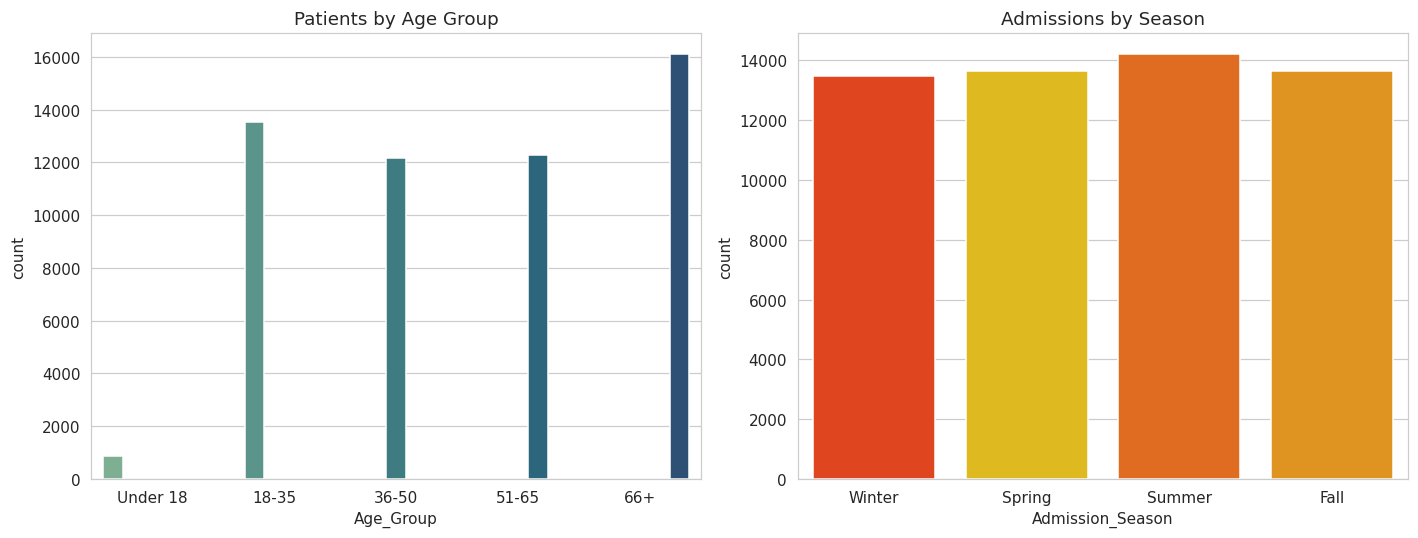

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=df, x="Age_Group", order=labels, hue="Age_Group", legend=False, palette="crest", ax=axes[0])
axes[0].set_title("Patients by Age Group")

sns.countplot(data=df, x="Admission_Season", order=["Winter", "Spring", "Summer", "Fall"], hue="Admission_Season", legend=False, palette="autumn", ax=axes[1])
axes[1].set_title("Admissions by Season")
plt.tight_layout()
plt.show()

In [21]:
weekend_share = df["Is_Weekend_Admission"].mean() * 100
extended_share = df["Discharge_Delay_Flag"].mean() * 100
print(f"Weekend admissions: {weekend_share:.1f}% of all admissions")
print(f"Extended stays (>20 days): {extended_share:.1f}% of all admissions")

Weekend admissions: 28.5% of all admissions
Extended stays (>20 days): 33.4% of all admissions


## 6. Feature Summary & Export

Preview the fully engineered dataset and save it for use in `billing_analysis.ipynb`.

In [22]:
engineered_cols = [
    "Name", "Age", "Age_Group", "Gender", "Blood Type", "Medical Condition",
    "Date of Admission", "Admission_Year", "Admission_Month", "Admission_DayOfWeek",
    "Admission_Season", "Is_Weekend_Admission", "Discharge Date", "Length_of_Stay",
    "LOS_Category", "Discharge_Delay_Flag", "Doctor", "Doctor_Patient_Count",
    "Hospital", "Hospital_Patient_Count", "Insurance Provider", "Billing Amount",
    "Billing_Per_Day", "Room Number", "Admission Type", "Medication", "Test Results"
]

engineered_df = df[engineered_cols]
engineered_df.to_csv("engineered_healthcare_dataset.csv", index=False)
print("Saved engineered_healthcare_dataset.csv —", engineered_df.shape)
engineered_df.head()

Saved engineered_healthcare_dataset.csv — (54966, 27)


,Name,Age,Age_Group,Gender,Blood Type,Medical Condition,Date of Admission,Admission_Year,Admission_Month,Admission_DayOfWeek,Admission_Season,Is_Weekend_Admission,Discharge Date,Length_of_Stay,LOS_Category,Discharge_Delay_Flag,Doctor,Doctor_Patient_Count,Hospital,Hospital_Patient_Count,Insurance Provider,Billing Amount,Billing_Per_Day,Room Number,Admission Type,Medication,Test Results
0,Bobby Jackson,30,18-35,Male,B-,Cancer,2024-01-31,2024,1,Wednesday,Winter,False,2024-02-02,2,Short (1-3 days),False,Matthew Smith,17,Sons and Miller,7,Blue Cross,18856.281306,9428.14,328,Urgent,Paracetamol,Normal
1,Leslie Terry,62,51-65,Male,A+,Obesity,2019-08-20,2019,8,Tuesday,Summer,False,2019-08-26,6,Medium (4-10 days),False,Samantha Davies,1,Kim Inc,6,Medicare,33643.327287,5607.22,265,Emergency,Ibuprofen,Inconclusive
2,Danny Smith,76,66+,Female,A-,Obesity,2022-09-22,2022,9,Thursday,Fall,False,2022-10-07,15,Long (11-20 days),False,Tiffany Mitchell,1,Cook PLC,4,Aetna,27955.096079,1863.67,205,Emergency,Aspirin,Normal
3,Andrew Watts,28,18-35,Female,O+,Diabetes,2020-11-18,2020,11,Wednesday,Fall,False,2020-12-18,30,Extended (21+ days),True,Kevin Wells,1,"Hernandez Rogers and Vang,",1,Medicare,37909.782410,1263.66,450,Elective,Ibuprofen,Abnormal
4,Adrienne Bell,43,36-50,Female,AB+,Cancer,2022-09-19,2022,9,Monday,Fall,False,2022-10-09,20,Long (11-20 days),False,Kathleen Hanna,2,White-White,2,Aetna,14238.317814,711.92,458,Urgent,Penicillin,Abnormal
